In [1]:
import scanpy as sc 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

import scipy.sparse as sp 
import warnings
import torch

warnings.filterwarnings("ignore")

import os
import ctypes
import sys

# 1. 先设置 R_HOME
os.environ["R_HOME"] = "/home/pxy/miniconda3/envs/r40/lib/R"

# 2. 【核心黑科技】手动加载 R 的动态库
# 这步操作等同于在终端里设置 LD_LIBRARY_PATH，专门解决 VS Code 找不到库的问题
try:
    # 这是 R 的核心库路径
    libR_path = "/home/pxy/miniconda3/envs/r40/lib/R/lib/libR.so"
    # 强制加载进内存
    ctypes.CDLL(libR_path, mode=ctypes.RTLD_GLOBAL)
    print("✅ 成功强制加载 libR.so")
except OSError as e:
    print(f"❌ 加载失败: {e}")

# 3. 然后再导入其他包
sys.path.append("..") 

import spCLUE
import rpy2.robjects as robjects
print("R 环境路径:", robjects.r['R.home']()[0])

spCLUE.fix_seed(0)

✅ 成功强制加载 libR.so
R 环境路径: /home/pxy/miniconda3/envs/r40/lib/R


In [2]:
sample_name="151669"
n_clusters = 5 if sample_name in [str(151669 + x) for x in range(4)] else 7
data_dir  = '/home/pxy/home/pxy/data/DLPFC/st/'

# data_file = f"../dataset/DLPFC/{sample_name}.h5ad"
# adata = sc.read_h5ad(data_file)
adata = sc.read_visium(data_dir + sample_name)
adata.var_names_make_unique()
print(adata)

AnnData object with n_obs × n_vars = 3661 × 33538
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'


In [3]:
import pandas as pd

meta = pd.read_csv(
    data_dir+sample_name+"/metadata.tsv",
    sep="\t"
)

meta = meta.set_index("barcode")
adata.obs["Region"] = meta.loc[
    adata.obs_names,
    "layer_guess_reordered"
]
print(adata.obs["Region"].value_counts())
print("NA spots:", adata.obs["Region"].isna().sum())

Region
Layer3    2141
Layer5     510
Layer6     391
Layer4     364
WM         230
Name: count, dtype: int64
NA spots: 25


In [4]:
adata = spCLUE.preprocess(adata)
adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
g_spatia = spCLUE.prepare_graph(adata, "spatial")
g_expr = spCLUE.prepare_graph(adata, "expr", metric="euclidean")
graph_dict = {"spatial": g_spatia, "expr":g_expr}

normalized data ---------------->


正在构建图: spatial, 使用度量: cosine ...
  -> 使用空间坐标 (euclidean)
  -> 计算最近邻 (NearestNeighbors)...
  -> 对称化与归一化...
spatial graph created successfully <----

正在构建图: expr, 使用度量: euclidean ...
  -> 使用 PCA 表达特征
  -> 计算最近邻 (NearestNeighbors)...
  -> 对称化与归一化...
expr graph created successfully <----



In [5]:
# adata = spCLUE.preprocess(adata)
# # adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)
# g_spatia = spCLUE.prepare_graph(adata, "spatial",radius=560)
# g_expr = spCLUE.prepare_graph(adata, "expr", metric="cosine",n_neighbors=14)
# graph_dict = {"spatial": g_spatia, "expr":g_expr}

In [6]:
input_data = adata.X.toarray() if sp.issparse(adata.X) else adata.X
model = spCLUE.spCLUE_TwoStage(
    adata.obsm["X_pca"], 
    # input_data,
    graph_dict, 
    n_clusters=n_clusters,
    dim_input=200,
    pretrain_epochs=100,   # 预训练200轮
    finetune_epochs=100,   # 训练300轮
    gamma=1.0,             # 重构损失权重
    beta=0.0,              # 聚类损失权重=0 (关键!)
    kappa=1.0,             # 对比损失权重
    dim_hidden=32,
    freeze_encoder=True,   # 冻结预训练编码器
    graph_corr=0.4,
    dropout=0.1,
    residual_weight=0.1
)

In [7]:
pred, embed = model.train()


Stage 1: Pre-training Shared Encoder


Pretrain:  25%|██▌       | 25/100 [00:01<00:03, 22.72it/s]

  Pretrain Epoch 10: Rec Loss = 11.218847
  Pretrain Epoch 20: Rec Loss = 11.047928
  Pretrain Epoch 30: Rec Loss = 10.927493


Pretrain:  61%|██████    | 61/100 [00:02<00:00, 61.57it/s]

  Pretrain Epoch 40: Rec Loss = 10.890422
  Pretrain Epoch 50: Rec Loss = 10.865128
  Pretrain Epoch 60: Rec Loss = 10.828620


...

  Train Epoch 80: Loss = 19.347282,Rec Loss = 11.174166, Contrast Loss = 8.173116,  Cluster Loss = 0.000000


Finetune:  96%|█████████▌| 96/100 [00:02<00:00, 33.12it/s]

  Train Epoch 90: Loss = 19.331606,Rec Loss = 11.166264, Contrast Loss = 8.165342,  Cluster Loss = 0.000000


Finetune: 100%|██████████| 100/100 [00:03<00:00, 32.67it/s]

  Train Epoch 100: Loss = 19.314892,Rec Loss = 11.158544, Contrast Loss = 8.156347,  Cluster Loss = 0.000000

  Finetune Epoch 100:
    Total Loss   = 19.3149
    Rec Loss     = 11.1585
    Contrast Loss = 8.1563
    Gate: spatial=0.367±0.096, expr=0.633±0.096

✓ Finetune finished (max epochs reached)
  [Gate Stats] spatial=0.367±0.096, expr=0.633±0.096


In [8]:
# ========== 聚类 ==========
adata.obsm["spCLUE_twostage"] = embed
spCLUE.clustering(adata, n_clusters, key="spCLUE_twostage", refinement=True,cluster_methods='kmeans')

# ========== 评估 ==========
adata_filtered = adata[adata.obs.Region.notna()]
ARI = adjusted_rand_score(adata_filtered.obs["Region"], 
                          adata_filtered.obs["kmeans_refined"])
print(f"\nFinal ARI on {sample_name}: {ARI:.4f}")



Final ARI on 151669: 0.4342


In [9]:
# ========== 聚类 ==========
adata.obsm["spCLUE_twostage"] = embed
spCLUE.clustering(adata, n_clusters, key="spCLUE_twostage", refinement=True)

# ========== 评估 ==========
adata_filtered = adata[adata.obs.Region.notna()]
ARI = adjusted_rand_score(adata_filtered.obs["Region"], 
                          adata_filtered.obs["mclust_refined"])
print(f"\nFinal ARI on {sample_name}: {ARI:.4f}")


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%

Final ARI on 151669: 0.3652


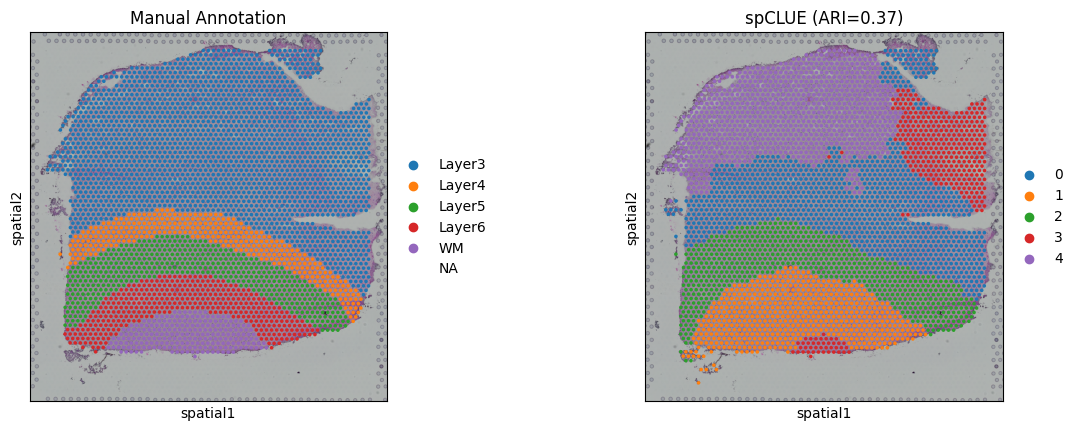

In [10]:
adata.obs["spCLUE"] = adata.obs["mclust_refined"]
sc.pl.spatial(adata, color=["Region", "spCLUE"], title=["Manual Annotation", f"spCLUE (ARI={round(ARI, 2)})"])